<a href="https://colab.research.google.com/github/rachelletjndr/datascience/blob/rasyel-1/INFEST_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn==1.5.2

In [ ]:
import os
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

In [ ]:
from google.colab import drive
drive.mount('/content.drive')

Drive already mounted at /content.drive; to attempt to forcibly remount, call drive.mount("/content.drive", force_remount=True).


In [ ]:
print("TensorFlow: ", tf.__version__)
print("GPU: ", tf.config.list_physical_devices("GPU"))

TensorFlow:  2.20.0
GPU:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
path_dataset = ("/content.drive/MyDrive/infest-xii-data-science")

In [ ]:
import os

DRIVE_ROOT = '/content.drive/MyDrive/infest-xii-data-science'
TRAIN_DIR = os.path.join(DRIVE_ROOT, 'images/train')
TEST_DIR  = os.path.join(DRIVE_ROOT, 'images/test')
TRAIN_CSV = os.path.join(DRIVE_ROOT, 'train.csv')
TEST_CSV  = os.path.join(DRIVE_ROOT, 'test.csv')
SUB_CSV   = os.path.join(DRIVE_ROOT, 'sample_submission.csv')

for name, p in [('TRAIN_DIR', TRAIN_DIR), ('TEST_DIR', TEST_DIR),
                ('TRAIN_CSV', TRAIN_CSV), ('TEST_CSV', TEST_CSV), ('SUB_CSV', SUB_CSV)]:
    print(('OK  ' if os.path.exists(p) else 'HILANG'), name, '->', p)

OK   TRAIN_DIR -> /content.drive/MyDrive/infest-xii-data-science/images/train
OK   TEST_DIR -> /content.drive/MyDrive/infest-xii-data-science/images/test
OK   TRAIN_CSV -> /content.drive/MyDrive/infest-xii-data-science/train.csv
OK   TEST_CSV -> /content.drive/MyDrive/infest-xii-data-science/test.csv
OK   SUB_CSV -> /content.drive/MyDrive/infest-xii-data-science/sample_submission.csv


In [ ]:
import os, shutil, time

USE_LOCAL_COPY = False   # set False kalau mau tetap baca langsung dari Drive

if USE_LOCAL_COPY:
    LOCAL_ROOT = '/content/data'
    t0 = time.time()
    if not os.path.exists(LOCAL_ROOT):
        shutil.copytree(DRIVE_ROOT, LOCAL_ROOT)
        print(f'Selesai menyalin dalam {time.time()-t0:.1f} detik')
    else:
        print('Folder lokal sudah ada, lewati penyalinan')

    TRAIN_DIR = os.path.join(LOCAL_ROOT, 'train')
    TEST_DIR  = os.path.join(LOCAL_ROOT, 'test')
    TRAIN_CSV = os.path.join(LOCAL_ROOT, 'train.csv')
    TEST_CSV  = os.path.join(LOCAL_ROOT, 'test.csv')
    SUB_CSV   = os.path.join(LOCAL_ROOT, 'sample_submission.csv')
    print('Path aktif sekarang:', LOCAL_ROOT)

In [ ]:
import pandas as pd

train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
sub   = pd.read_csv(SUB_CSV)

print('train.csv             :', train.shape, '| kolom:', list(train.columns))
print('test.csv              :', test.shape,  '| kolom:', list(test.columns))
print('sample_submission.csv :', sub.shape,   '| kolom:', list(sub.columns))
print()

print('Missing value train:', train.isna().sum().to_dict())
print('Missing value test :', test.isna().sum().to_dict())
print('Duplikat image_id train:', int(train['image_id'].duplicated().sum()))
print('Duplikat image_id test :', int(test['image_id'].duplicated().sum()))
print()

CLASSES = sorted(train['label'].unique())
print(f'{len(CLASSES)} kelas:', CLASSES)
print()
print(train.head())

train.csv             : (4468, 2) | kolom: ['image_id', 'label']
test.csv              : (1118, 1) | kolom: ['image_id']
sample_submission.csv : (1118, 2) | kolom: ['image_id', 'label']

Missing value train: {'image_id': 0, 'label': 0}
Missing value test : {'image_id': 0}
Duplikat image_id train: 0
Duplikat image_id test : 0

7 kelas: ['bali', 'jawa', 'jawi', 'lampung', 'lontara', 'pegon', 'sunda']

       image_id    label
0  SxrIaKaJ.png    pegon
1  XiR75p4l.png     jawi
2  gpadO4eH.png     jawa
3  IlL62jcp.png  lampung
4  7bEtcJPy.png     bali


In [ ]:
import os

def audit_folder(folder, csv_ids, nama):
    if not os.path.isdir(folder):
        print(f'[{nama}] FOLDER TIDAK ADA: {folder}')
        return {}, set(), set(), []

    semua = os.listdir(folder)
    gambar = {f for f in semua if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp'))}
    bukan_gambar = [f for f in semua if f not in gambar]

    csv_set = set(csv_ids)
    hilang = csv_set - gambar
    nyasar = gambar - csv_set

    print(f'--- {nama} ---')
    print(f'  Total isi folder      : {len(semua)}')
    print(f'  File gambar           : {len(gambar)}')
    print(f'  Terdaftar di CSV      : {len(csv_set)}')
    print(f'  HILANG (CSV, no file) : {len(hilang)}')
    print(f'  Nyasar (file, no CSV) : {len(nyasar)}')
    print(f'  Bukan gambar          : {len(bukan_gambar)} {sorted(bukan_gambar)[:5]}')
    if hilang:
        print('  Contoh hilang:', sorted(hilang)[:10])
    if nyasar:
        print('  Contoh nyasar:', sorted(nyasar)[:10])
    print()
    return gambar, hilang, nyasar, bukan_gambar

train_files, train_hilang, train_nyasar, _ = audit_folder(TRAIN_DIR, train['image_id'], 'TRAIN')
test_files,  test_hilang,  test_nyasar,  _ = audit_folder(TEST_DIR,  test['image_id'],  'TEST')

--- TRAIN ---
  Total isi folder      : 4471
  File gambar           : 4471
  Terdaftar di CSV      : 4468
  HILANG (CSV, no file) : 0
  Nyasar (file, no CSV) : 3
  Bukan gambar          : 0 []
  Contoh nyasar: ['8yjpTIAh (1).png', 'AfVBrFuS (1).png', 'c1RY5dfN (1).png']

--- TEST ---
  Total isi folder      : 1118
  File gambar           : 1118
  Terdaftar di CSV      : 1118
  HILANG (CSV, no file) : 0
  Nyasar (file, no CSV) : 0
  Bukan gambar          : 0 []



Kelas         Jumlah    Persen
lampung          823    18.42%
jawi             814    18.22%
pegon            771    17.26%
sunda            658    14.73%
jawa             653    14.62%
lontara          382     8.55%
bali             367     8.21%

Mayoritas : lampung (823)
Minoritas : bali (367)
Imbalance ratio (max/min) : 2.24x
=> Imbalance ringan. class_weight atau weighted sampler biasanya sudah cukup.


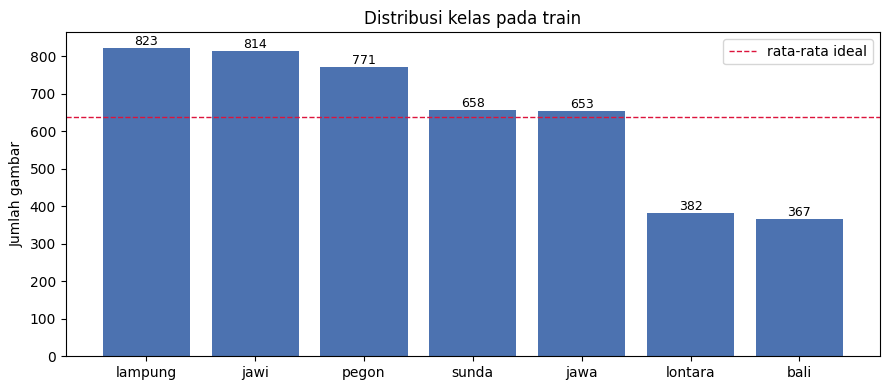

In [ ]:
import matplotlib.pyplot as plt

vc = train['label'].value_counts().sort_values(ascending=False)
n_total = len(train)

print('Kelas         Jumlah    Persen')
for k, v in vc.items():
    print(f'{k:<12} {v:>7}   {v/n_total*100:>6.2f}%')

rasio = vc.max() / vc.min()
print(f'\nMayoritas : {vc.idxmax()} ({vc.max()})')
print(f'Minoritas : {vc.idxmin()} ({vc.min()})')
print(f'Imbalance ratio (max/min) : {rasio:.2f}x')

if rasio < 1.5:
    print('=> Praktis seimbang.')
elif rasio < 3:
    print('=> Imbalance ringan. class_weight atau weighted sampler biasanya sudah cukup.')
elif rasio < 10:
    print('=> Imbalance sedang. Pertimbangkan class_weight + augmentasi kelas minoritas.')
else:
    print('=> Imbalance berat. Perlu penanganan khusus (focal loss / resampling).')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(vc.index, vc.values, color='#4C72B0')
ax.axhline(n_total / len(vc), ls='--', c='crimson', lw=1, label='rata-rata ideal')
for i, v in enumerate(vc.values):
    ax.text(i, v + 8, str(v), ha='center', fontsize=9)
ax.set_title('Distribusi kelas pada train')
ax.set_ylabel('Jumlah gambar')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
from concurrent.futures import ThreadPoolExecutor
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = False   # sengaja: biar file terpotong ketahuan

def probe(args):
    folder, fname = args
    path = os.path.join(folder, fname)
    rec = {'image_id': fname, 'ok': False, 'w': 0, 'h': 0, 'mode': '',
           'fmt': '', 'kb': 0.0, 'error': ''}
    try:
        rec['kb'] = os.path.getsize(path) / 1024
        with Image.open(path) as im:
            rec['w'], rec['h'] = im.size
            rec['mode'] = im.mode
            rec['fmt'] = im.format or ''
            im.load()                      # paksa baca penuh -> deteksi truncated
        rec['ok'] = True
    except Exception as e:
        rec['error'] = f'{type(e).__name__}: {e}'[:100]
    return rec

def scan(folder, ids, nama):
    ada = [i for i in ids if os.path.exists(os.path.join(folder, i))]
    print(f'Scanning {len(ada)} gambar di {nama} ...')
    with ThreadPoolExecutor(max_workers=16) as ex:
        recs = list(ex.map(probe, [(folder, i) for i in ada]))
    return pd.DataFrame(recs)

info_train = scan(TRAIN_DIR, train['image_id'], 'TRAIN')
info_test  = scan(TEST_DIR,  test['image_id'],  'TEST')
print('Selesai.')

Scanning 4468 gambar di TRAIN ...
Scanning 1118 gambar di TEST ...
Selesai.


In [ ]:
def lapor_gambar(info, nama):
    rusak = info[~info['ok']]
    ok = info[info['ok']]
    print(f'===== {nama} =====')
    print(f'Terbaca : {len(ok)} | RUSAK: {len(rusak)}')
    if len(rusak):
        print(rusak[['image_id', 'error']].head(20).to_string(index=False))
    if not len(ok):
        print()
        return

    print(f"\nLebar  : min {ok.w.min()}  median {int(ok.w.median())}  max {ok.w.max()}")
    print(f"Tinggi : min {ok.h.min()}  median {int(ok.h.median())}  max {ok.h.max()}")
    print(f"Ukuran file: median {ok.kb.median():.1f} KB  max {ok.kb.max():.1f} KB")
    print(f"\nMode warna : {ok['mode'].value_counts().to_dict()}")
    print(f"Format     : {ok['fmt'].value_counts().to_dict()}")

    ok = ok.copy()
    ok['dim'] = ok.w.astype(str) + 'x' + ok.h.astype(str)
    top = ok['dim'].value_counts()
    print(f"\nResolusi unik: {len(top)}")
    print('5 resolusi terbanyak:')
    for d, c in top.head(5).items():
        print(f'  {d:<14} {c:>5}  ({c/len(ok)*100:.1f}%)')

    ok['ar'] = ok.w / ok.h
    print(f"\nAspect ratio: min {ok.ar.min():.2f}  median {ok.ar.median():.2f}  max {ok.ar.max():.2f}")
    kecil = ok[(ok.w < 32) | (ok.h < 32)]
    if len(kecil):
        print(f'PERINGATAN: {len(kecil)} gambar berdimensi < 32px')
    print()
    return ok

ok_train = lapor_gambar(info_train, 'TRAIN')
ok_test  = lapor_gambar(info_test,  'TEST')

===== TRAIN =====
Terbaca : 4467 | RUSAK: 1
    image_id                                                                                                error
mPmaODVU.png UnidentifiedImageError: cannot identify image file '/content.drive/MyDrive/infest-xii-data-science/i

Lebar  : min 14  median 289  max 1590
Tinggi : min 15  median 64  max 266
Ukuran file: median 3.0 KB  max 146.1 KB

Mode warna : {'RGB': 4467}
Format     : {'PNG': 4467}

Resolusi unik: 3937
5 resolusi terbanyak:
  44x54             19  (0.4%)
  40x35              9  (0.2%)
  142x36             8  (0.2%)
  124x56             7  (0.2%)
  147x36             6  (0.1%)

Aspect ratio: min 0.18  median 4.74  max 29.10
PERINGATAN: 132 gambar berdimensi < 32px

===== TEST =====
Terbaca : 1118 | RUSAK: 0

Lebar  : min 14  median 293  max 1557
Tinggi : min 15  median 63  max 633
Ukuran file: median 3.5 KB  max 174.4 KB

Mode warna : {'RGB': 1118}
Format     : {'PNG': 1118}

Resolusi unik: 1064
5 resolusi terbanyak:
  147x36    

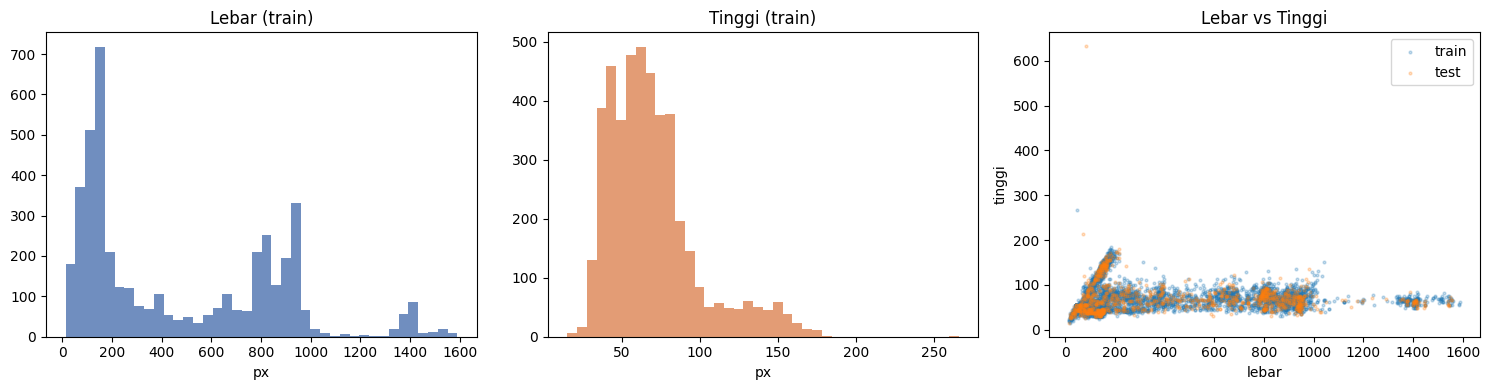

In [ ]:
# Sebaran dimensi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(ok_train.w, bins=40, color='#4C72B0', alpha=.8)
axes[0].set_title('Lebar (train)'); axes[0].set_xlabel('px')

axes[1].hist(ok_train.h, bins=40, color='#DD8452', alpha=.8)
axes[1].set_title('Tinggi (train)'); axes[1].set_xlabel('px')

axes[2].scatter(ok_train.w, ok_train.h, s=4, alpha=.25, label='train')
axes[2].scatter(ok_test.w, ok_test.h, s=4, alpha=.25, label='test')
axes[2].set_title('Lebar vs Tinggi'); axes[2].set_xlabel('lebar'); axes[2].set_ylabel('tinggi')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
import hashlib
import numpy as np
from PIL import Image

def md5_of(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for blok in iter(lambda: f.read(65536), b''):
            h.update(blok)
    return h.hexdigest()

def ahash_of(path, size=8):
    try:
        with Image.open(path) as im:
            g = im.convert('L').resize((size, size), Image.Resampling.LANCZOS)
        a = np.asarray(g, dtype=np.float32)
        bits = (a > a.mean()).flatten()
        return ''.join('1' if b else '0' for b in bits)
    except Exception:
        return None

def hash_folder(folder, ids, nama):
    ada = [i for i in ids if os.path.exists(os.path.join(folder, i))]
    print(f'Hashing {len(ada)} gambar di {nama} ...')
    with ThreadPoolExecutor(max_workers=16) as ex:
        md5s = list(ex.map(lambda i: md5_of(os.path.join(folder, i)), ada))
        ah   = list(ex.map(lambda i: ahash_of(os.path.join(folder, i)), ada))
    return pd.DataFrame({'image_id': ada, 'md5': md5s, 'ahash': ah, 'split': nama})

h_train = hash_folder(TRAIN_DIR, train['image_id'], 'train')
h_test  = hash_folder(TEST_DIR,  test['image_id'],  'test')
h_train = h_train.merge(train, on='image_id', how='left')
print('Selesai.')

Hashing 4468 gambar di train ...
Hashing 1118 gambar di test ...
Selesai.


In [ ]:
# --- duplikat persis di dalam train ---
dup = h_train[h_train.duplicated('md5', keep=False)].sort_values('md5')
print(f'Gambar identik (MD5) di dalam TRAIN : {len(dup)} file dalam {dup.md5.nunique()} grup')

konflik = 0
if len(dup):
    for m, g in dup.groupby('md5'):
        if g['label'].nunique() > 1:
            konflik += 1
            if konflik <= 10:
                print(f'  KONFLIK LABEL: {list(g.image_id)} -> {list(g.label)}')
    print(f'Grup dengan label bertentangan: {konflik}')

# --- duplikat persis di dalam test ---
dup_te = h_test[h_test.duplicated('md5', keep=False)]
print(f'\nGambar identik (MD5) di dalam TEST  : {len(dup_te)} file')

# --- kebocoran train <-> test ---
bocor = set(h_train.md5) & set(h_test.md5)
print(f'\nKEBOCORAN train<->test (MD5 sama)  : {len(bocor)} gambar')
if bocor:
    contoh = h_test[h_test.md5.isin(bocor)].head(10)
    print(contoh[['image_id', 'md5']].to_string(index=False))

Gambar identik (MD5) di dalam TRAIN : 0 file dalam 0 grup

Gambar identik (MD5) di dalam TEST  : 0 file

KEBOCORAN train<->test (MD5 sama)  : 0 gambar


In [ ]:
# --- near-duplicate via aHash (hash identik = sangat mirip) ---
va = h_train.dropna(subset=['ahash'])
near = va[va.duplicated('ahash', keep=False)]
grup_near = near.ahash.nunique()
print(f'Near-duplicate di TRAIN : {len(near)} file dalam {grup_near} grup aHash')

if grup_near:
    beda_label = 0
    for a, g in near.groupby('ahash'):
        if g['label'].nunique() > 1:
            beda_label += 1
            if beda_label <= 10:
                print(f'  Mirip tapi beda label: {list(g.image_id)} -> {list(g.label)}')
    print(f'Grup mirip dengan label berbeda: {beda_label}')

vt = h_test.dropna(subset=['ahash'])
bocor_near = set(va.ahash) & set(vt.ahash)
print(f'\nNear-duplicate train<->test : {len(bocor_near)} grup aHash beririsan')
print('(aHash kasar — beberapa gambar polos/putih bisa bertabrakan. Verifikasi visual dulu sebelum menghapus.)')

Near-duplicate di TRAIN : 210 file dalam 64 grup aHash
  Mirip tapi beda label: ['ID4kcQrj.png', 'KaJX1CaJ.png', 'qsb0qvpf.png'] -> ['jawa', 'bali', 'jawa']
  Mirip tapi beda label: ['G3p5m44L.png', 'CDYxjO2v.png', 's3gRCrqz.png', 'BDpH623z.png', 'LZGykrzn.png', 'Un4dHFMd.png', 'xZRdzdNE.png', 'CaYYTk8c.png', 'mcmf86Hu.png', 'jqkobH59.png', 'eFUZ8YM2.png', 'ooXBUwyI.png', '0Z2Jjwaj.png', 'jMM7yQDq.png', '5sy0IqlF.png'] -> ['jawa', 'jawa', 'bali', 'jawa', 'jawa', 'jawa', 'jawa', 'bali', 'jawa', 'bali', 'jawa', 'jawa', 'bali', 'jawa', 'bali']
  Mirip tapi beda label: ['e414zUvj.png', 'kCichgDl.png'] -> ['jawa', 'sunda']
  Mirip tapi beda label: ['KlctSWiv.png', '0ftw03VZ.png', 'vbf6KYBq.png'] -> ['lampung', 'sunda', 'sunda']
  Mirip tapi beda label: ['osf2Mk0K.png', 'jt0aqwhU.png'] -> ['sunda', 'jawi']
  Mirip tapi beda label: ['npFTkZEl.png', 'ZItUwMcz.png', 'gW1e4HMQ.png'] -> ['jawa', 'sunda', 'sunda']
  Mirip tapi beda label: ['4cClALn9.png', 'XPfGOOyB.png'] -> ['sunda', 'jawi']
  Mir

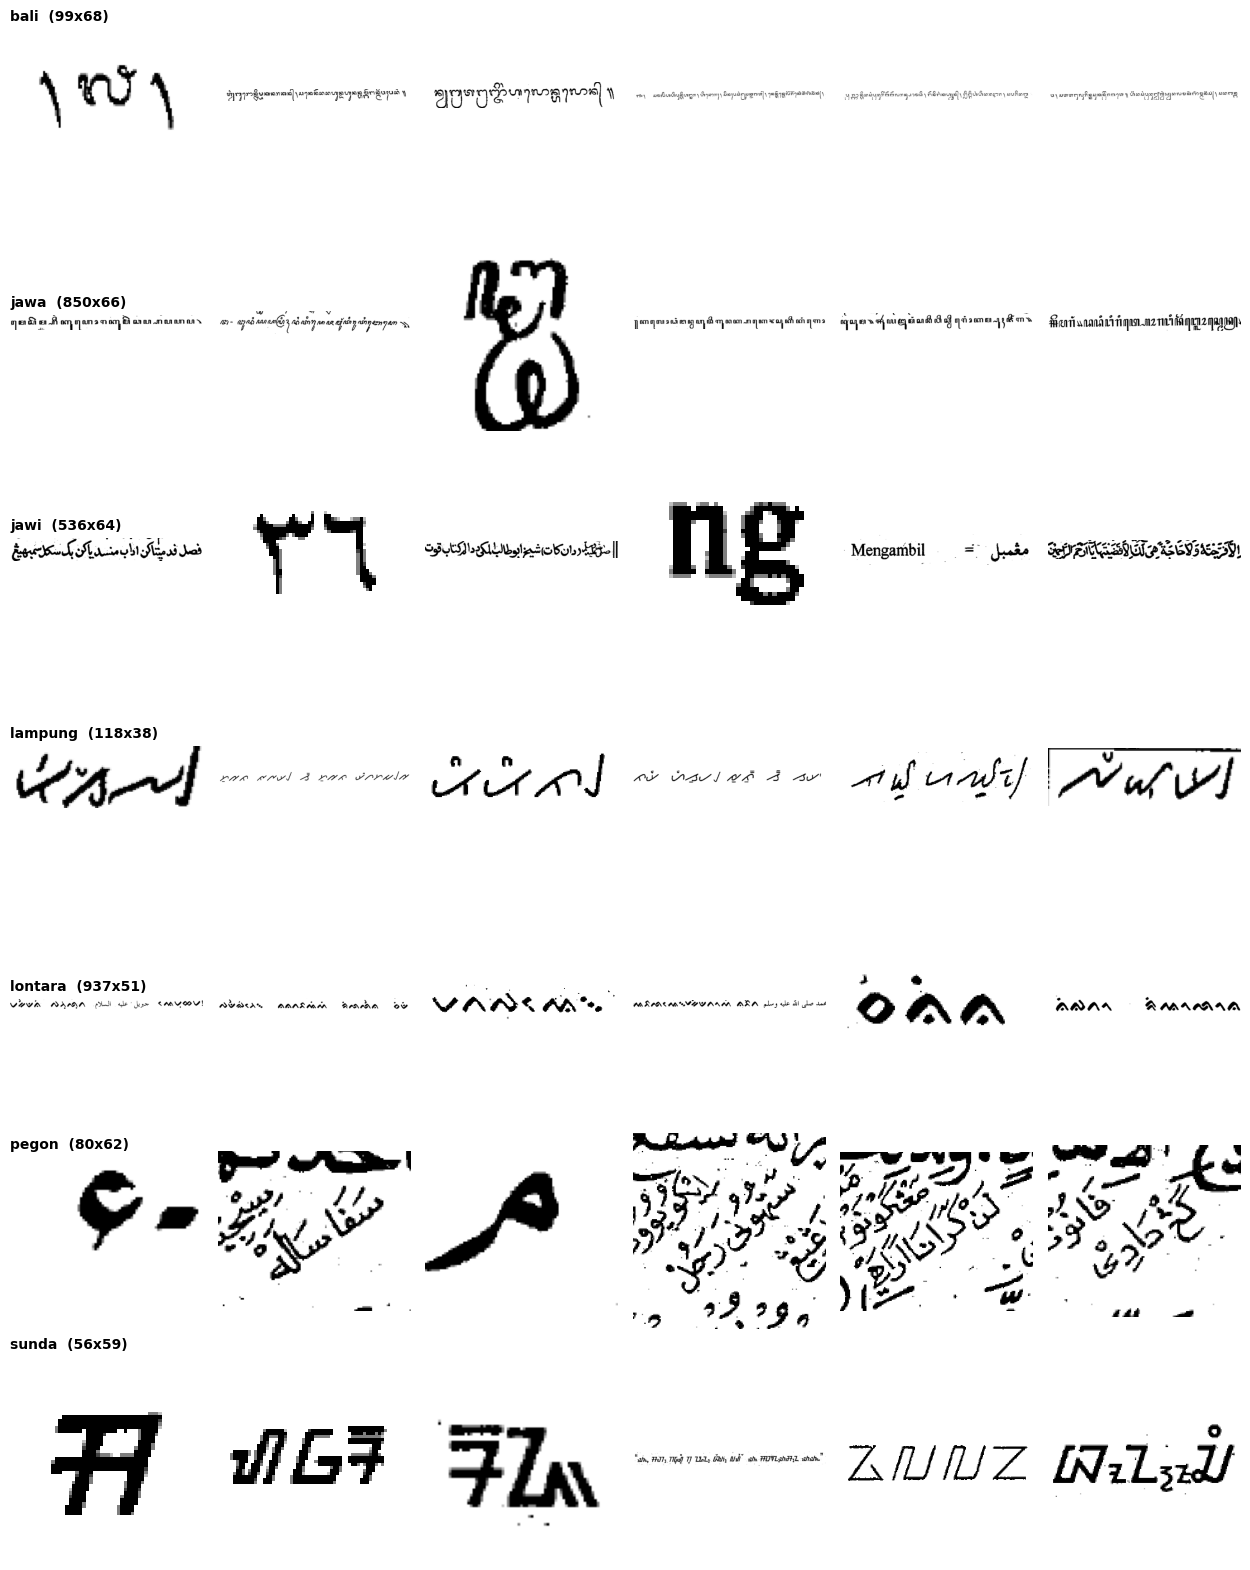

In [ ]:
import random
from PIL import Image

N_PER_KELAS = 6
random.seed(42)

fig, axes = plt.subplots(len(CLASSES), N_PER_KELAS,
                         figsize=(N_PER_KELAS * 2.1, len(CLASSES) * 2.3))

for r, kelas in enumerate(CLASSES):
    sampel = train[train.label == kelas].sample(
        min(N_PER_KELAS, (train.label == kelas).sum()), random_state=42)
    for c in range(N_PER_KELAS):
        ax = axes[r, c]
        ax.axis('off')
        if c < len(sampel):
            fid = sampel.iloc[c]['image_id']
            p = os.path.join(TRAIN_DIR, fid)
            try:
                with Image.open(p) as im:
                    ax.imshow(im.convert('RGB'))
                if c == 0:
                    ax.set_title(f'{kelas}  ({im.size[0]}x{im.size[1]})',
                                 loc='left', fontsize=10, fontweight='bold')
            except Exception as e:
                ax.text(.5, .5, 'GAGAL', ha='center', va='center', color='red')

plt.tight_layout()
plt.show()

In [ ]:
!pip install scikeras

In [ ]:
import pandas as pd
import math

target_min = 750
upsampled_dfs = []

print("Proses Upsampling Dinamis (Multiplier):")
for cls in CLASSES:
    df_cls = train[train['label'] == cls]
    count = len(df_cls)

    # Jika jumlah sampel di bawah target, kalikan datanya
    if count < target_min:
        # Menghitung faktor pengali (misal: 300 data -> 800/300 = 2.6 -> dibulatkan ke atas jadi 3x)
        multiplier = math.ceil(target_min / count)
        print(f" - Kelas {cls:<8}: {count} gambar -> di-upsample {multiplier}x menjadi {count * multiplier} gambar")

        # Menggandakan dataframe sesuai multiplier
        df_cls = pd.concat([df_cls] * multiplier, ignore_index=True)
    else:
        print(f" - Kelas {cls:<8}: {count} gambar -> tidak di-upsample")

    upsampled_dfs.append(df_cls)

# Menggabungkan kembali dataframe
train_upsampled = pd.concat(upsampled_dfs).reset_index(drop=True)

print("\nDistribusi kelas setelah upsampling dinamis:")
print(train_upsampled['label'].value_counts())

Proses Upsampling Dinamis (Multiplier):
 - Kelas bali    : 367 gambar -> di-upsample 3x menjadi 1101 gambar
 - Kelas jawa    : 653 gambar -> di-upsample 2x menjadi 1306 gambar
 - Kelas jawi    : 814 gambar -> tidak di-upsample
 - Kelas lampung : 823 gambar -> tidak di-upsample
 - Kelas lontara : 382 gambar -> di-upsample 2x menjadi 764 gambar
 - Kelas pegon   : 771 gambar -> tidak di-upsample
 - Kelas sunda   : 658 gambar -> di-upsample 2x menjadi 1316 gambar

Distribusi kelas setelah upsampling dinamis:
label
sunda      1316
jawa       1306
bali       1101
lampung     823
jawi        814
pegon       771
lontara     764
Name: count, dtype: int64


In [ ]:
!pip install seaborn

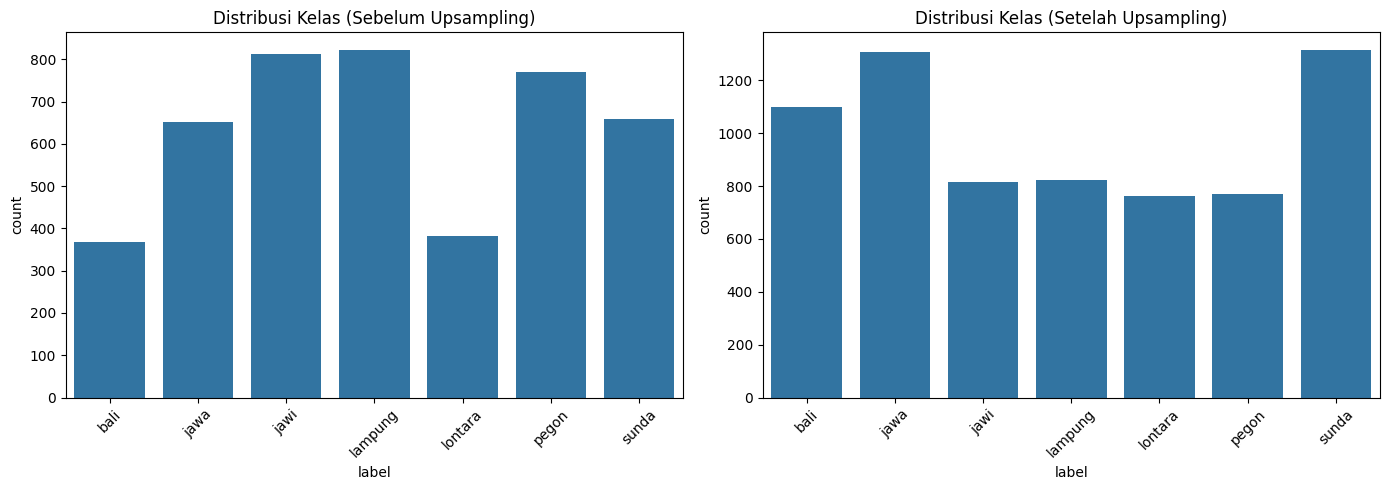

In [ ]:
import seaborn as sns

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=train, x='label', order=CLASSES)
plt.title('Distribusi Kelas (Sebelum Upsampling)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(data=train_upsampled, x='label', order=CLASSES)
plt.title('Distribusi Kelas (Setelah Upsampling)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 224 # Sesuaikan menjadi 224 jika RAM memungkinkan

def load_images_and_labels(df, img_dir):
    X = []
    y = []
    for idx, row in df.iterrows():
        img_path = os.path.join(img_dir, row['image_id'])
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(row['label'])
    return np.array(X), np.array(y)

print("Memuat gambar ke dalam memori...")
X_train, y_train_labels = load_images_and_labels(train_upsampled, TRAIN_DIR)

# Encode label string menjadi integer
le = LabelEncoder()
y_train = le.fit_transform(y_train_labels)

Memuat gambar ke dalam memori...


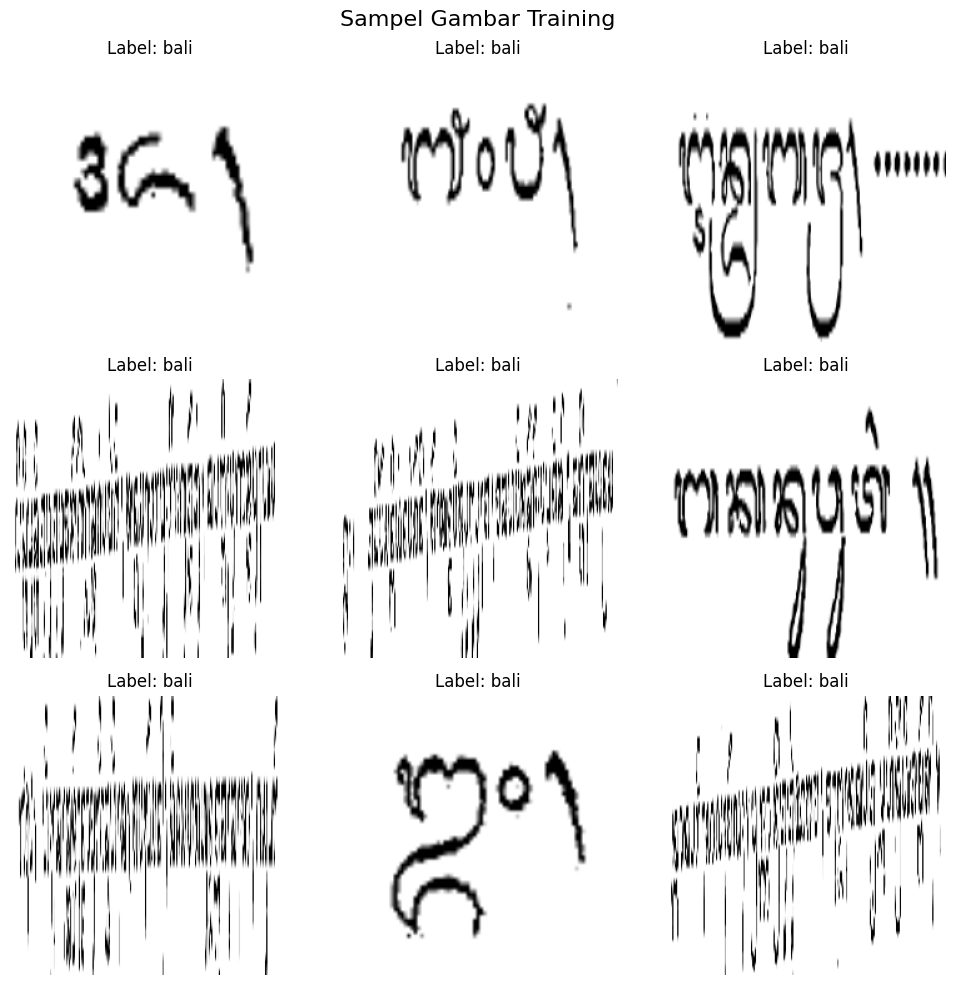

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {y_train_labels[i]}")
    plt.axis("off")
plt.suptitle("Sampel Gambar Training", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
# Tambahkan 'Input' pada import layers Anda
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam, SGD
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

def create_model(optimizer='adam', learning_rate=0.001):
    # 1. Preprocessing & Augmentasi Data
    data_augmentation = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.1)
    ], name="preprocessing_augmentation")

    # 2. Base Model EfficientNetB0
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    # 3. Klasifikasi
    model = Sequential([
        # ---> SOLUSI: Deklarasikan Input shape secara eksplisit di sini
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        base_model,
        GlobalAveragePooling2D(),
        Dense(len(le.classes_), activation='softmax')
    ])

    # 4. Pengaturan Optimizer dan Learning Rate
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Membungkus fungsi Keras untuk kompatibilitas dengan Scikit-Learn
model = KerasClassifier(
    model=create_model,
    verbose=0,
    optimizer='adam',
    learning_rate=0.001
)

# Menentukan parameter tuning
param_grid = {
    'batch_size': [16, 32],
    'epochs': [5, 10],
    'optimizer': ['adam', 'sgd'],
    'learning_rate': [0.001, 0.0001]
}

# Setup GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1
)

print("Memulai GridSearchCV (ini mungkin membutuhkan waktu yang cukup lama)...")
# Menjalankan tuning grid search
grid_result = grid.fit(X_train, y_train)

print(f"Akurasi Terbaik: {grid_result.best_score_:.4f}")
print(f"Kombinasi Parameter Terbaik: {grid_result.best_params_}")

# Menyimpan model terbaik
best_model = grid_result.best_estimator_

Memulai GridSearchCV (ini mungkin membutuhkan waktu yang cukup lama)...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.13/dist-packages/numpy/ma/core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Akurasi Terbaik: 0.9252
Kombinasi Parameter Terbaik: {'batch_size': 16, 'epochs': 10, 'learning_rate': 0.001, 'optimizer': 'adam'}


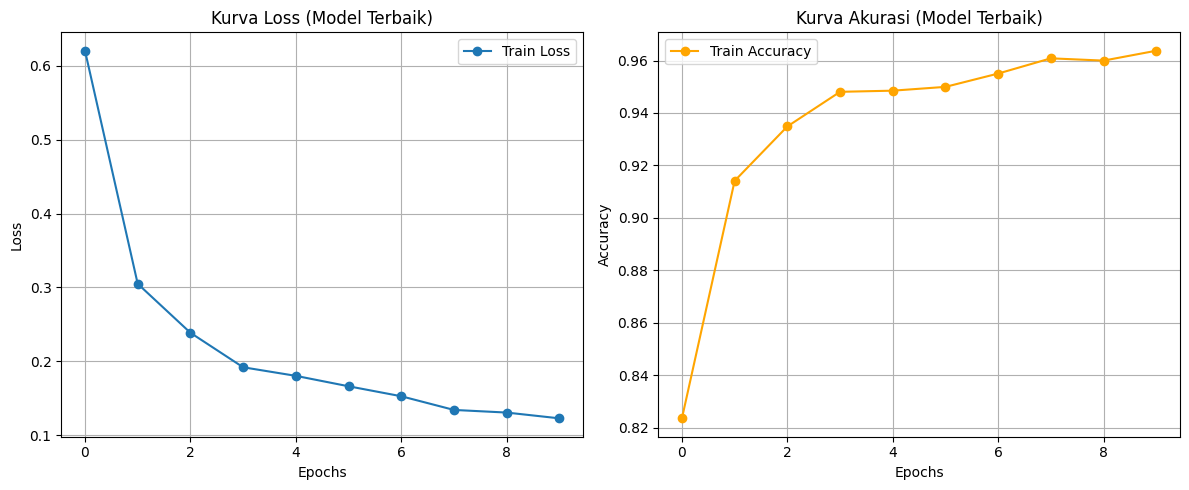

In [ ]:
best_history = best_model.history_

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_history['loss'], label='Train Loss', marker='o')
plt.title('Kurva Loss (Model Terbaik)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(best_history['accuracy'], label='Train Accuracy', marker='o', color='orange')
plt.title('Kurva Akurasi (Model Terbaik)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Membuat prediksi untuk Confusion Matrix...


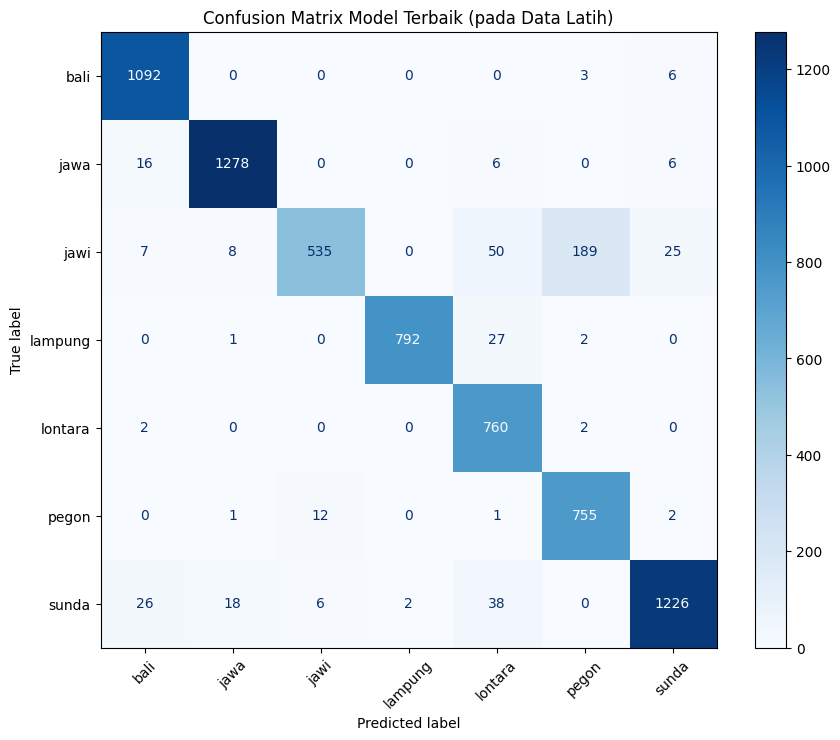

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Membuat prediksi untuk Confusion Matrix...")
y_pred = best_model.predict(X_train)

cm = confusion_matrix(y_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix Model Terbaik (pada Data Latih)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

print("\n=== 1. METRIK EVALUASI ===")
# Classification Report & F1/Accuracy
print(classification_report(y_train, y_pred, target_names=le.classes_))
print(f"Accuracy Score: {accuracy_score(y_train, y_pred):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_train, y_pred, average='weighted'):.4f}")

# ROC-AUC & Precision-Recall
# Dapatkan probabilitas prediksi untuk kalkulasi kurva
y_pred_probs = best_model.predict_proba(X_train)
y_train_bin = label_binarize(y_train, classes=range(len(le.classes_)))

print("\n=== 2. ROC-AUC & PRECISION-RECALL PER KELAS ===")
for i, class_name in enumerate(le.classes_):
    # Kurva ROC dan AUC
    fpr, tpr, _ = roc_curve(y_train_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    # Kurva Precision-Recall dan Average Precision
    precision, recall, _ = precision_recall_curve(y_train_bin[:, i], y_pred_probs[:, i])
    avg_precision = average_precision_score(y_train_bin[:, i], y_pred_probs[:, i])

    print(f"- Kelas '{class_name}': AUC = {roc_auc:.4f} | Avg Precision = {avg_precision:.4f}")


=== 1. METRIK EVALUASI ===
              precision    recall  f1-score   support

        bali       0.96      0.99      0.97      1101
        jawa       0.98      0.98      0.98      1306
        jawi       0.97      0.66      0.78       814
     lampung       1.00      0.96      0.98       822
     lontara       0.86      0.99      0.92       764
       pegon       0.79      0.98      0.88       771
       sunda       0.97      0.93      0.95      1316

    accuracy                           0.93      6894
   macro avg       0.93      0.93      0.92      6894
weighted avg       0.94      0.93      0.93      6894

Accuracy Score: 0.9339
F1 Score (Weighted): 0.9319

=== 2. ROC-AUC & PRECISION-RECALL PER KELAS ===
- Kelas 'bali': AUC = 0.9998 | Avg Precision = 0.9988
- Kelas 'jawa': AUC = 0.9997 | Avg Precision = 0.9988
- Kelas 'jawi': AUC = 0.9900 | Avg Precision = 0.9453
- Kelas 'lampung': AUC = 0.9999 | Avg Precision = 0.9990
- Kelas 'lontara': AUC = 0.9994 | Avg Precision = 0.9970

In [ ]:
import pandas as pd
import numpy as np
import cv2
import os

print("\n=== 3. PERSIAPAN SUBMISSION KAGGLE ===")
X_test = []
test_valid_ids = []

print("Memuat gambar test ke memori...")
for idx, row in test.iterrows():
    img_path = os.path.join(TEST_DIR, row['image_id'])
    img = cv2.imread(img_path)

    # Pastikan gambar terbaca dengan baik
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X_test.append(img)
        test_valid_ids.append(row['image_id'])
    else:
        print(f"Peringatan: Gambar {row['image_id']} tidak terbaca dan akan dilewati.")

X_test = np.array(X_test)

# Prediksi menggunakan model terbaik hasil GridSearchCV
print("Melakukan prediksi pada data test...")
test_preds = best_model.predict(X_test)

# Kembalikan prediksi integer menjadi label string aslinya
test_preds_labels = le.inverse_transform(test_preds)

# Buat dataframe sesuai format sample_submission
submission_df = pd.DataFrame({
    'image_id': test_valid_ids,
    'label': test_preds_labels
})

# Simpan ke CSV tanpa index
submission_csv_path = 'submission.csv'
submission_df.to_csv(submission_csv_path, index=False)
print(f"\nSelesai! File '{submission_csv_path}' berhasil dibuat.")
print(submission_df.head())


=== 3. PERSIAPAN SUBMISSION KAGGLE ===
Memuat gambar test ke memori...
Melakukan prediksi pada data test...

Selesai! File 'submission.csv' berhasil dibuat.
       image_id    label
0  AQmumubg.png  lampung
1  nbXfeFmw.png     jawi
2  mUdL9acm.png    pegon
3  FgSrN0Ad.png    pegon
4  n7xv3e7m.png  lontara
